<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Actividad_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Ejercicio: Tibasa**

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

<img src="https://lh3.googleusercontent.com/drive-storage/AJQWtBOpz22EVgDSbtaq1_4AhAFktO9ZNOvZ6xSwpYYgnAo1ycwBbobYvaRlSgGmxUcJqMpFvjOQhjkpT8MdE1dwLFVCISCBvzUNd8KbdO2S2B_0Uyo3bQ=w1852-h870?auditContext=forDisplay" width="600" height="300">

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

### Paso 1: Definimos las variables.

Sea $$X_i: \text{Peso de cada tina} $$

Con $$X_i \sim \text{Triangular (a=190 kg, b=230 kg, c=210 kg)} $$

In [8]:
# Imoortamos las librerías
import random as r
import math
import matplotlib.pyplot as plt

In [9]:
# Parámetros
a = 190
b = 230
c = 210
N = 10000

Aplicando transformación inversa distribución triangular:

$$ F(c) = \frac{c-a}{b-a}$$

con

$$
X = \begin{cases}
      a + \sqrt{R(b-a)(c-a)} & R \leq 0.5 \\
      b - \sqrt{(1-R)(b-a)(b-c)} & R > 0.5
   \end{cases}
$$

In [10]:
def triangular():
    R =r.random() #Generamos R uniforme
    Fc =(c - a)/(b - a) #Calculamos F(c)

    if R <= Fc:
        X = a + math.sqrt(R * (b - a) * (c - a))
    else:
        X = b - math.sqrt((1 - R) * (b - a) * (b - c))

    return X


sumas=[] # Guardar sumas
excesos=0 # Contador de excesos

for i in range(N):
    S=0
    for j in range(5):
        S+=triangular()
    sumas.append(S)

    if S > 1000:
        excesos+=1

# Probabilidad estimada
probabilidad = excesos/N

print("Probabilidad estimada =",probabilidad)


Probabilidad estimada = 0.9976


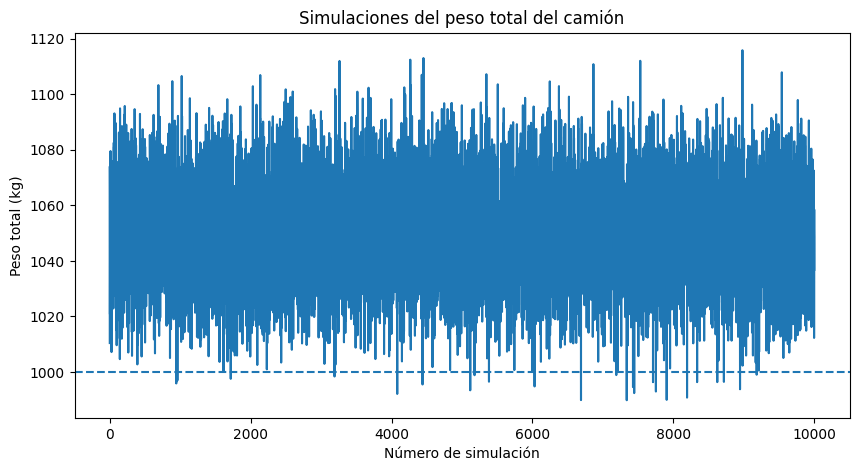

In [11]:
#Grafica de las simulaciones
plt.figure(figsize=(10,5))
plt.plot(range(1, N+1), sumas)
plt.axhline(1000, linestyle='--')
plt.xlabel("Número de simulación")
plt.ylabel("Peso total (kg)")
plt.title("Simulaciones del peso total del camión")
plt.show()

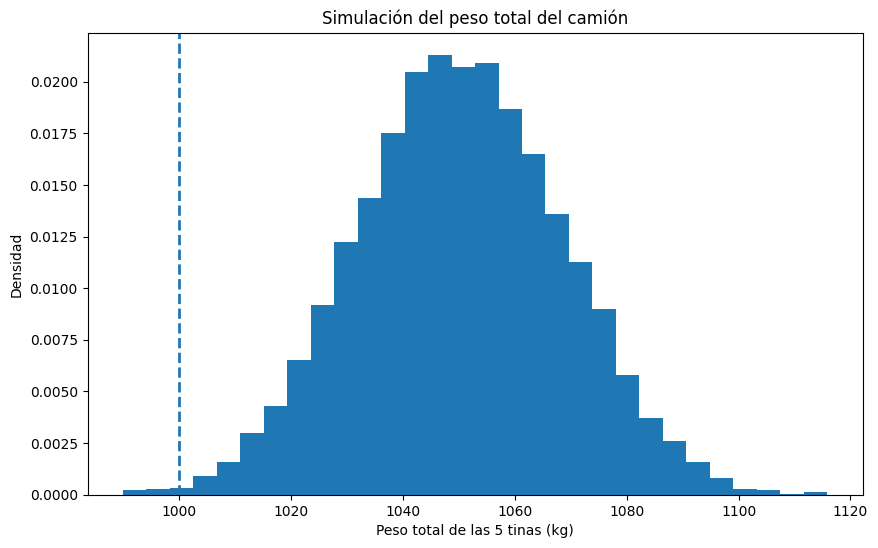

In [12]:
#Grafica histgrama
plt.figure(figsize=(10,6))
plt.hist(sumas,bins=30,density=True)
plt.axvline(1000, linestyle='--', linewidth=2) #Línea que marca el tope de capacidad
plt.xlabel("Peso total de las 5 tinas (kg)")
plt.ylabel("Densidad")
plt.title("Simulación del peso total del camión")
plt.show()